PART A — Implementation (s = 011)

In [6]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np

In [7]:
def simon_oracle():
    
    qc = QuantumCircuit(6)
    
    # Copy input register to output register
    qc.cx(0,3)
    qc.cx(1,4)
    qc.cx(2,5)
    
    # Implement secret string structure
    qc.cx(1,5)
    qc.cx(2,4)
    
    return qc

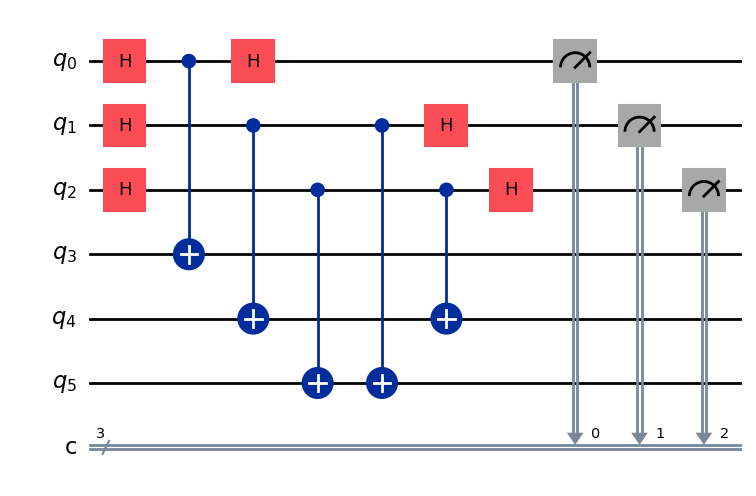

In [8]:
qc = QuantumCircuit(6,3)

# Apply Hadamard to input register
qc.h([0,1,2])

# Add oracle
qc.compose(simon_oracle(), inplace=True)

# Second Hadamard layer
qc.h([0,1,2])

# Measure input register
qc.measure([0,1,2],[0,1,2])

qc.draw('mpl')

In [9]:
backend = Aer.get_backend('qasm_simulator')

job = backend.run(qc, shots=2000)
result = job.result()

counts = result.get_counts()

plot_histogram(counts)
counts


{'110': 485, '000': 509, '111': 521, '001': 485}

1. Role of the FIRST Hadamard gates

Answer: Each H gate maps |0⟩ → (|0⟩ + |1⟩)/√2, creates superposition over all input states, enabling the quantum circuit to evaluate the function for multiple inputs simultaneously.

2. Role of the oracle

Answer:  Encodes the hidden function f satisfying f(x) = f(x ⊕ s). It entangles the input register with an output register such that the output qubit state reflects f(x). After the oracle, the combined state contains pairs |x⟩|f(x)⟩ and |x⊕s⟩|f(x)⟩ in superposition. This creates interference that the second Hadamard layer exploits.

3. Role of the SECOND Hadamard layer

Answer: Applied again to the input register after the oracle.This performs a Hadamard transform, which causes constructive interference only for states u satisfying u · s = 0

4. Role of Measurement

Answer: Measurement collapses the quantum state and provides bit strings 𝑢 that form linear equations used to determine the secret string.

5. Why outputs satisfy 𝑢 ⋅ 𝑠 = 0?

Answer: Due to quantum interference produced by the Hadamard transform, only states orthogonal to s remain with non-zero probability.

Part B: 5-bit Implementation (s = 10110)

In [10]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np

In [11]:
secret = "10110"
n = len(secret)

In [12]:
def simon_oracle_5():

    qc = QuantumCircuit(10)

    # Copy input register to output register
    for i in range(5):
        qc.cx(i, i+5)

    # Add XOR structure based on secret string
    for i, bit in enumerate(secret):
        if bit == "1":
            qc.cx(i, 9)

    return qc

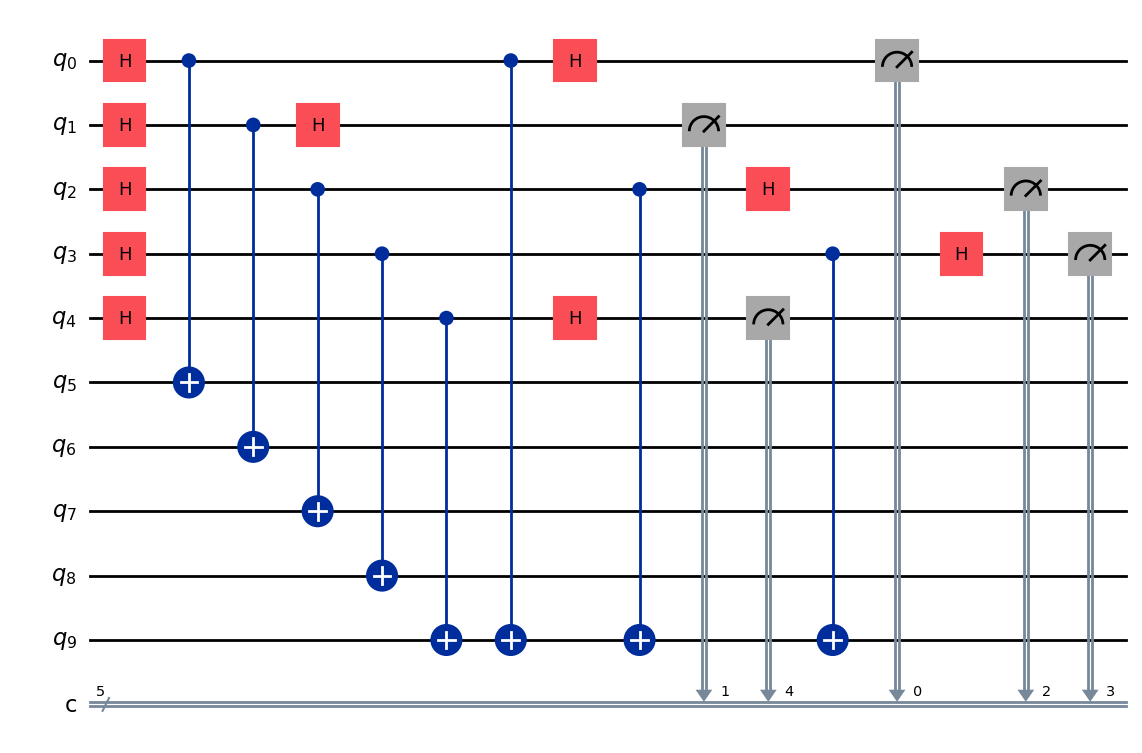

In [13]:
qc = QuantumCircuit(10,5)

# First Hadamard
qc.h(range(5))

# Oracle
qc.compose(simon_oracle_5(), inplace=True)

# Second Hadamard
qc.h(range(5))

# Measurement
qc.measure(range(5), range(5))

qc.draw('mpl')

In [14]:
backend = Aer.get_backend('qasm_simulator')

job = backend.run(qc, shots=2000)
result = job.result()

counts = result.get_counts()

plot_histogram(counts)
counts

{'01110': 61,
 '00011': 78,
 '01100': 65,
 '01001': 59,
 '01010': 69,
 '00010': 59,
 '01011': 58,
 '10011': 80,
 '10010': 53,
 '11011': 66,
 '11001': 66,
 '10100': 68,
 '11111': 59,
 '01000': 60,
 '00111': 71,
 '00110': 76,
 '00100': 81,
 '10001': 54,
 '11000': 74,
 '00000': 60,
 '10110': 57,
 '10101': 62,
 '00001': 55,
 '01101': 50,
 '10000': 71,
 '11010': 50,
 '00101': 54,
 '10111': 55,
 '01111': 70,
 '11100': 50,
 '11110': 61,
 '11101': 48}

In [15]:
valid_strings = []

for key,value in counts.items():
    if key != "00000":
        valid_strings.append(key)

print("Measured strings u:")
print(valid_strings)

Measured strings u:
['01110', '00011', '01100', '01001', '01010', '00010', '01011', '10011', '10010', '11011', '11001', '10100', '11111', '01000', '00111', '00110', '00100', '10001', '11000', '10110', '10101', '00001', '01101', '10000', '11010', '00101', '10111', '01111', '11100', '11110', '11101']


PART C — Classical Post Processing

In [16]:
import numpy as np

# measured u strings (replace with your results)
U = [
    [1,0,0,1,1],
    [0,1,1,0,0],
    [1,1,0,1,0],
    [0,0,1,1,1]
]

U = np.array(U) % 2

# Solve Us = 0 mod 2

from sympy import Matrix

M = Matrix(U)

nullspace = M.nullspace()

print("Recovered secret string basis:")
print(nullspace)

Recovered secret string basis:
[Matrix([
[-1],
[ 1],
[-1],
[ 0],
[ 1]])]
